In [1439]:
import pandas as pd
import numpy as np
import seaborn as sns  #visualisation
import matplotlib.pyplot as plt  #visualisation
from sklearn.model_selection import train_test_split
%matplotlib inline
sns.set_theme(color_codes=True)

In [1440]:
df = pd.read_csv('student_lifestyle_100k.csv')
df.head(2)

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False


In [1441]:
# Убираем Student_ID, т.к. он не несёт смысловой нагрузки для обучения модели
df.drop(columns=['Student_ID'], inplace=True)

df.rename(columns={"Age": "age",
                   "Gender": "gender",
                   "Department": "department",
                   "CGPA": "grade",
                   "Sleep_Duration": "sleep_hours",
                   "Study_Hours": "study_hours",
                   "Social_Media_Hours": "social_hours",
                   "Physical_Activity": "physical_minutes_week",
                   "Stress_Level": "stress",
                   "Depression": "depression",
                   }, inplace=True)

df = df[df['sleep_hours'] + df['study_hours'] + df['social_hours'] <= 24]

print("Пропуски: ", df.isnull().sum().sum())
print("Дубликаты:", df.duplicated().sum())

Пропуски:  0
Дубликаты: 0


,age,gender,department,grade,sleep_hours,study_hours,social_hours,physical_minutes_week,stress,depression
count,99921.000000,99921,99921,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921
unique,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Male,Science,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,50078,20056,NaN,NaN,NaN,NaN,NaN,NaN,89864
mean,21.008887,NaN,NaN,2.898246,6.994291,4.505956,3.501174,74.352458,4.131504,NaN
std,2.000381,NaN,NaN,0.532189,1.496934,1.972359,1.485036,43.363229,1.424150,NaN
min,18.000000,NaN,NaN,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,NaN
25%,19.000000,NaN,NaN,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,NaN
50%,21.000000,NaN,NaN,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,NaN
75%,23.000000,NaN,NaN,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,NaN


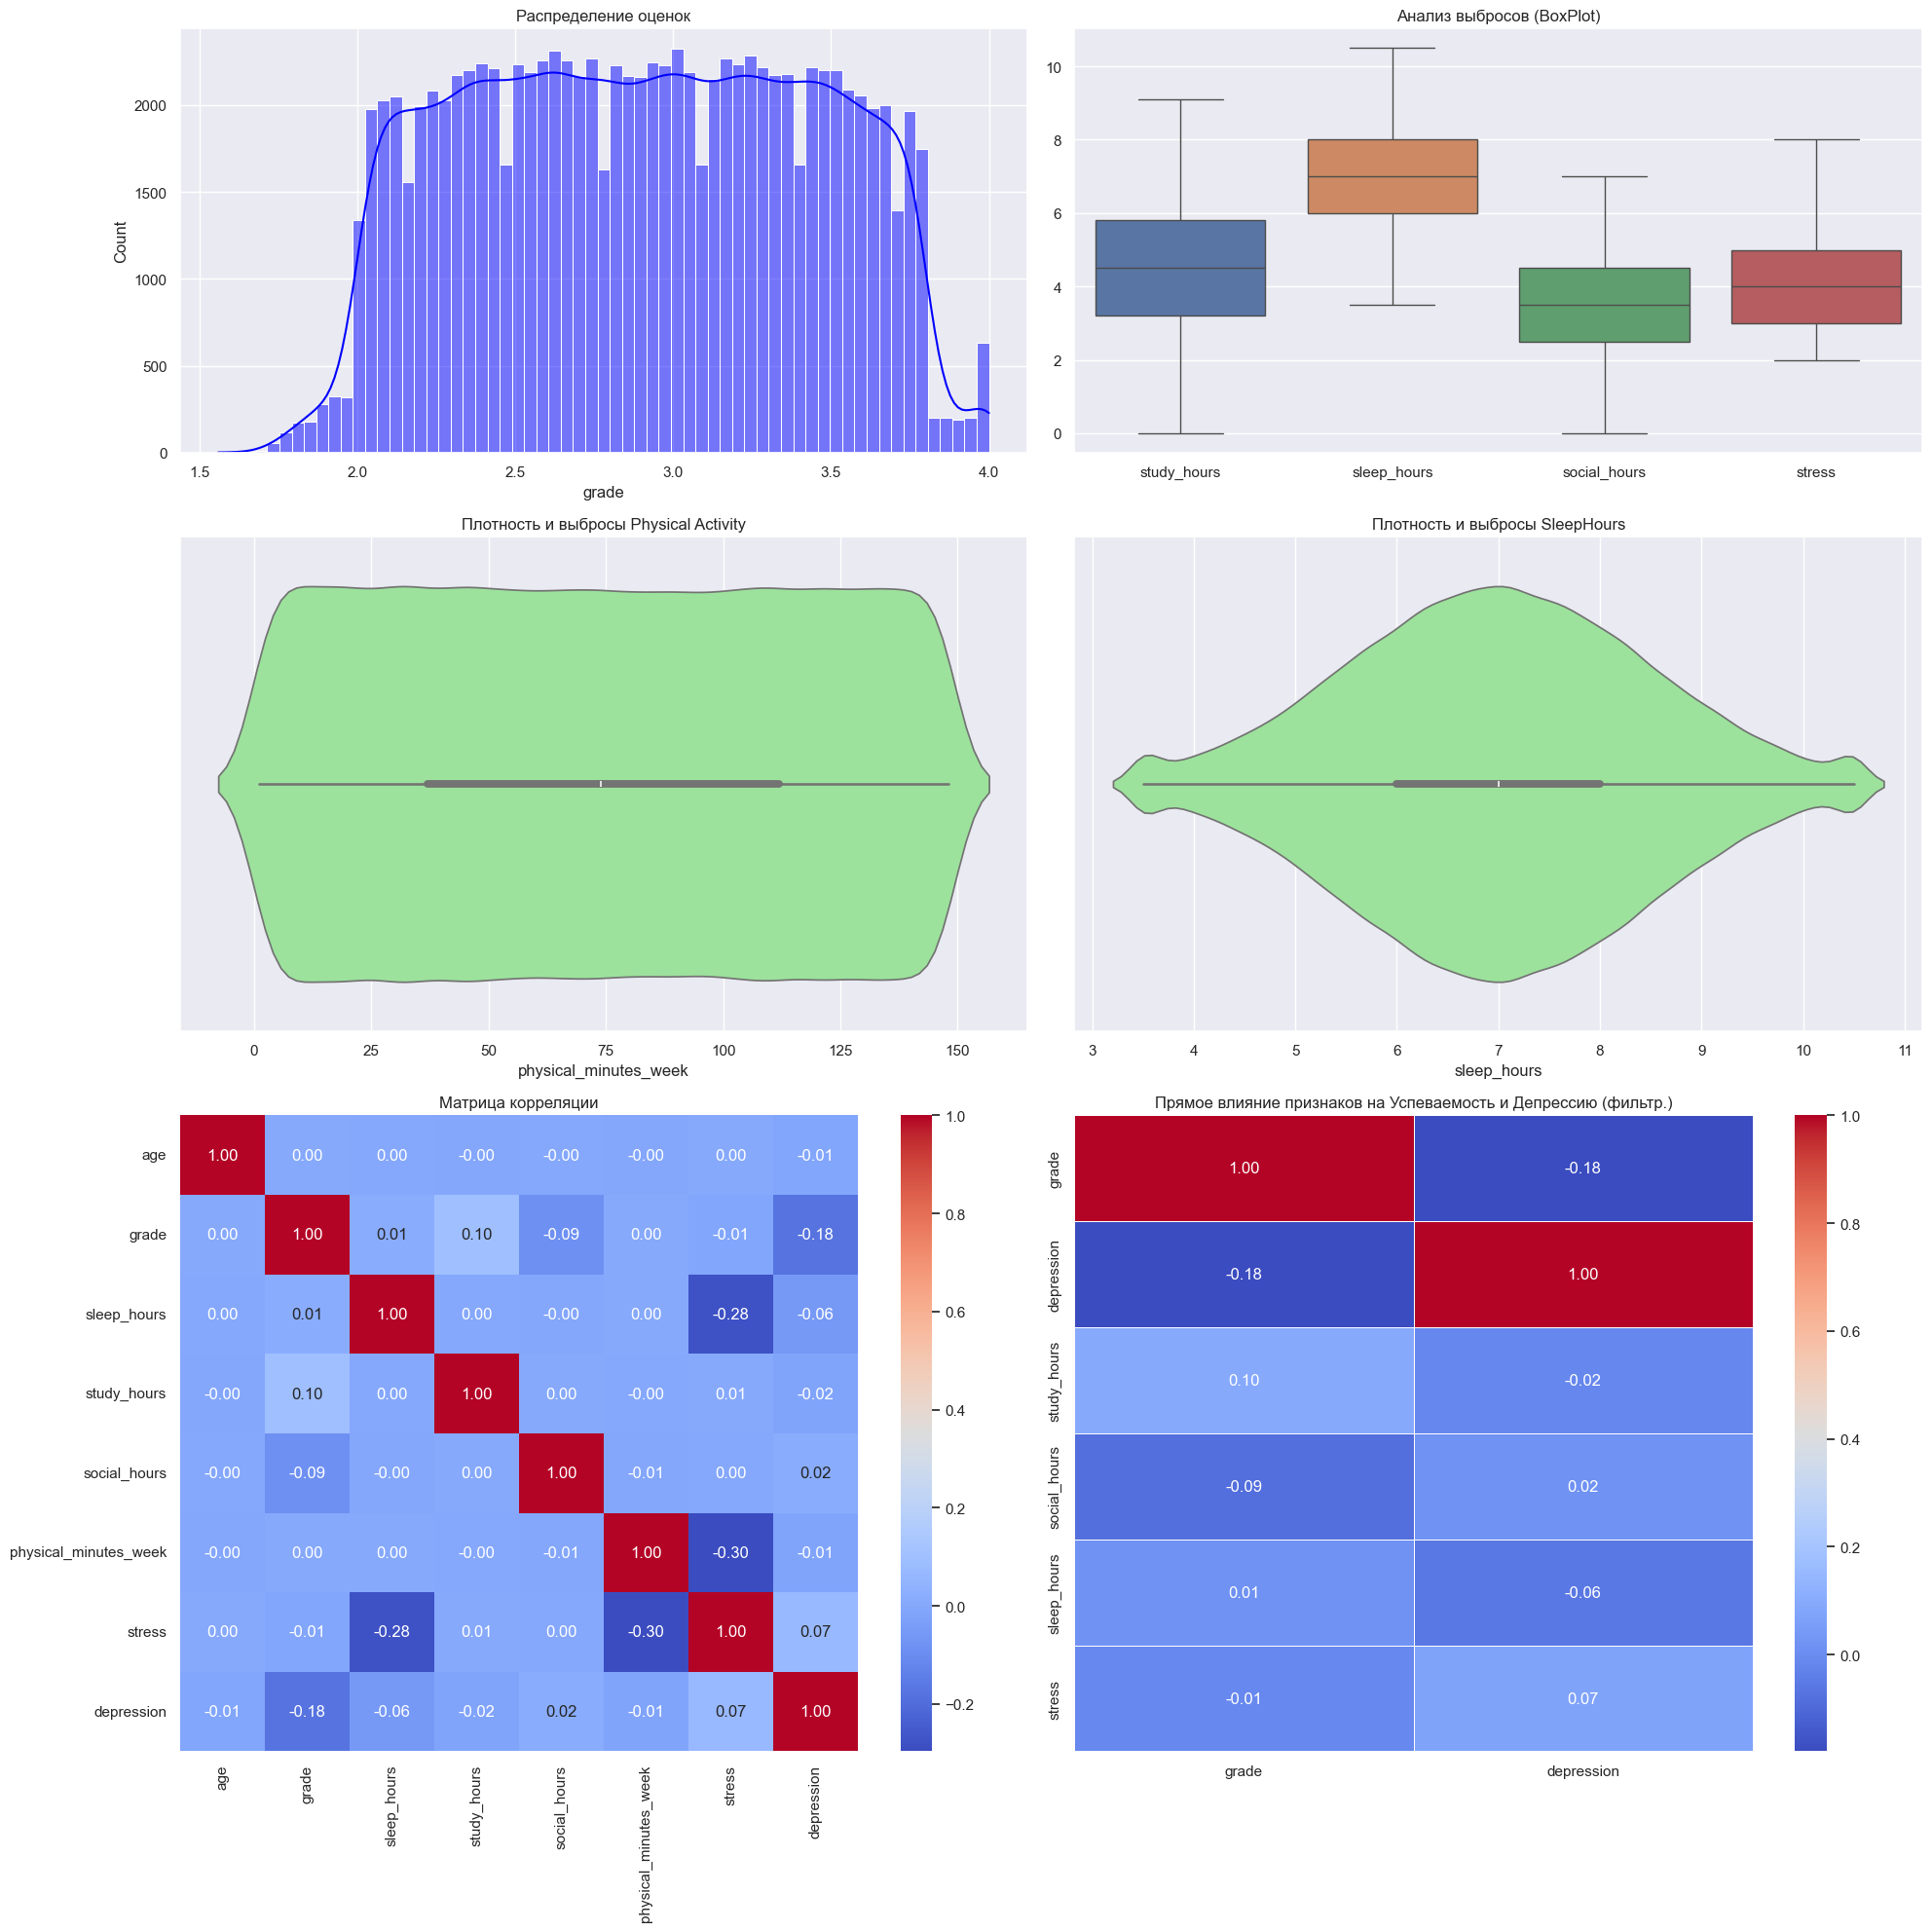

In [1442]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

display(df.describe(include='all'))

fig, axes = plt.subplots(3, 2, figsize=(20, 20),
                         gridspec_kw={'height_ratios': [0.6, 0.7, 0.9], 'width_ratios': [1, 1]})

sns.histplot(df['grade'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Распределение оценок')

# TODO: обработка выбросов
# numeric_cols = df.select_dtypes(include=[np.number]).columns
# for col in numeric_cols:
#     lower = df[col].quantile(0.01)
#     upper = df[col].quantile(0.99)
#     df[col] = df[col].clip(lower, upper)

sns.boxplot(data=df[['study_hours', 'sleep_hours', 'social_hours', 'stress']], ax=axes[0, 1])
axes[0, 1].set_title('Анализ выбросов (BoxPlot)')

sns.violinplot(x=df['physical_minutes_week'], color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Плотность и выбросы Physical Activity')

sns.violinplot(x=df['sleep_hours'], color='lightgreen', ax=axes[1, 1])
axes[1, 1].set_title('Плотность и выбросы SleepHours')

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2, 0])
axes[2, 0].set_title('Матрица корреляции')

# Добавим строковые значения
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_encoded_data = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(
    ohe_encoded_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)
ohe_df = pd.concat([df.drop(columns=cat_cols), ohe_df], axis=1)

target_corr = ohe_df.corr()[['grade', 'depression']].sort_values(by='grade', ascending=False, key=lambda x: x.abs())
threshold = 0.015
important_features = target_corr[(target_corr['grade'].abs() > threshold) |
                                 (target_corr['depression'].abs() > threshold)]

sns.heatmap(important_features, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('Прямое влияние признаков на Успеваемость и Депрессию (фильтр.)')

plt.tight_layout()
plt.show()

df = ohe_df



#### Успеваемость (`grade`):
- Влияет больше всего: `depression`, `study_hours`, `social_hours`
- Не влияет: `age`, `department`, `gender` и `physical_minutes_week`

#### Депрессия (`depression`):
- Влияет больше всего: `grade`, `stress` и `sleep_hours`
- Не влияет: `age`, `department`, `gender` и `physical_minutes_week`


## Подготовка для Регрессии

In [1443]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.pipeline import Pipeline

to_keep = ['study_hours', 'sleep_hours', 'social_hours', 'stress', 'grade', 'depression']
df = df[to_keep]


# from practice5
def evaluate_regression(y_true, y_pred, dataset_name, feature, weights, prev_metrics=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    current_metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

    descriptions = {
        'MAE': 'средняя абсолютная ошибка (чем меньше, тем точнее)',
        'RMSE': 'среднеквадратичная ошибка (сильнее штрафует за большие промахи)',
        'R2': 'коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)',
        'MAPE': 'средняя ошибка в процентах (показывает масштаб отклонения)'
    }

    print(f"\n📊 Метрики для {dataset_name}:")

    for key, val in current_metrics.items():
        diff_str = ""
        if prev_metrics and key in prev_metrics:
            diff = val - prev_metrics[key]
            color = "+" if diff > 0 else ""
            diff_str = f" ({color}{diff:.4f})"

        unit = "%" if key == "MAPE" else ""
        desc = descriptions.get(key, "")
        print(f"  {key}: {val:,.4f}{unit}{diff_str}    – {desc}")

    importance = pd.DataFrame({'feature': feature, 'weight': weights.flatten()})
    importance = importance.sort_values(by='weight', ascending=False, key=lambda x: x.abs())

    print("\n=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===")
    print(importance.head(10))

    return current_metrics


def draw_actual_vs_predict_grade(test, pred, name):
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=test, y=pred, alpha=0.3, color='blue')
    plt.plot([test.min(), test.max()], [test.min(), test.max()], '--r', linewidth=2)
    plt.xlabel('Реальный Grade')
    plt.ylabel('Предсказанный Grade')
    plt.title(f'Actual vs Predicted ({name})')
    plt.show()


def regression_metrics(x, y, name, use_poly, prev_metrics=None):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, shuffle=True
    )
    print(f"Размер обучающей выборки: {x_train.shape[0]}")
    print(f"Размер тестовой выборки: {x_test.shape[0]}")

    steps = []
    if use_poly:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))

    steps.append(('scaler', StandardScaler()))
    steps.append(('model', LinearRegression()))

    pipeline = Pipeline(steps)
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    if use_poly:
        feature_names = pipeline.named_steps['poly'].get_feature_names_out(x.columns)
    else:
        feature_names = x.columns

    metrics = evaluate_regression(y_test, y_pred, name,
                                  feature=feature_names,
                                  weights=pipeline.named_steps['model'].coef_, prev_metrics=prev_metrics)
    draw_actual_vs_predict_grade(y_test, y_pred, name)
    return metrics


## Сырое (без своих фич)

Размер обучающей выборки: 79936
Размер тестовой выборки: 19985

📊 Метрики для Linear Regression (without features):
  MAE: 0.4415    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5151    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0462    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 15.9674%    – средняя ошибка в процентах (показывает масштаб отклонения)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
        feature    weight
4    depression -0.093388
0   study_hours  0.049374
2  social_hours -0.044848
1   sleep_hours  0.003257
3        stress -0.000730


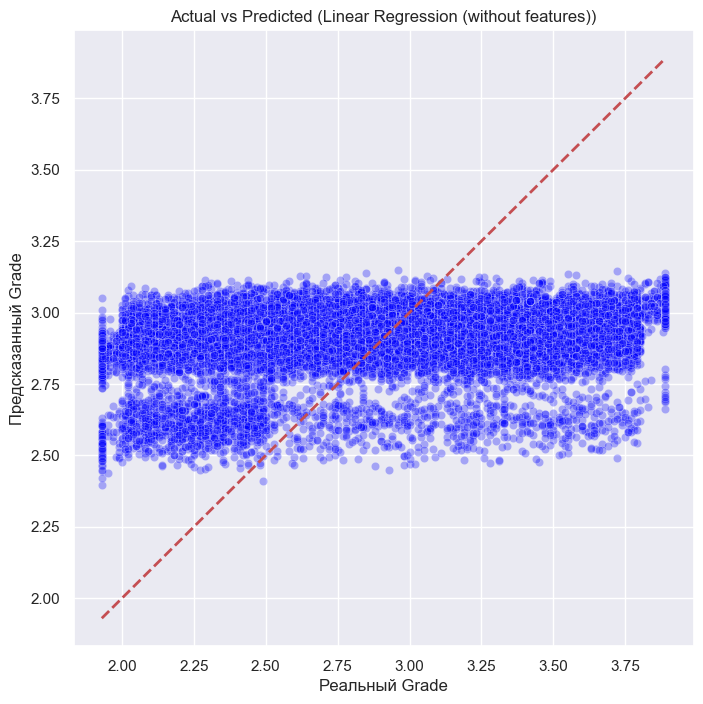

In [1444]:
x_raw_reg = df.drop(columns=['grade'])
y_raw_reg = df['grade']

raw_metrics = regression_metrics(x_raw_reg, y_raw_reg, "Linear Regression (without features)", use_poly=False)

## С доп признаками (Feature Engineering)

Размер обучающей выборки: 79936
Размер тестовой выборки: 19985

📊 Метрики для Linear Regression (with features):
  MAE: 0.4393 (-0.0022)    – средняя абсолютная ошибка (чем меньше, тем точнее)
  RMSE: 0.5118 (-0.0032)    – среднеквадратичная ошибка (сильнее штрафует за большие промахи)
  R2: 0.0582 (+0.0120)    – коэффициент детерминации (чем ближе к 1, тем лучше модель объясняет данные)
  MAPE: 15.8763% (-0.0911)    – средняя ошибка в процентах (показывает масштаб отклонения)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
                                        feature    weight
40                   stress stress_sleep_impact  0.751702
37                                     stress^2 -0.546074
41               stress study_with_stress_ratio  0.493480
56  stress_sleep_impact study_with_stress_ratio -0.405940
0                                   study_hours -0.369316
6                           stress_sleep_impact -0.343502
10                                study_hours^2  0.295033
16              st

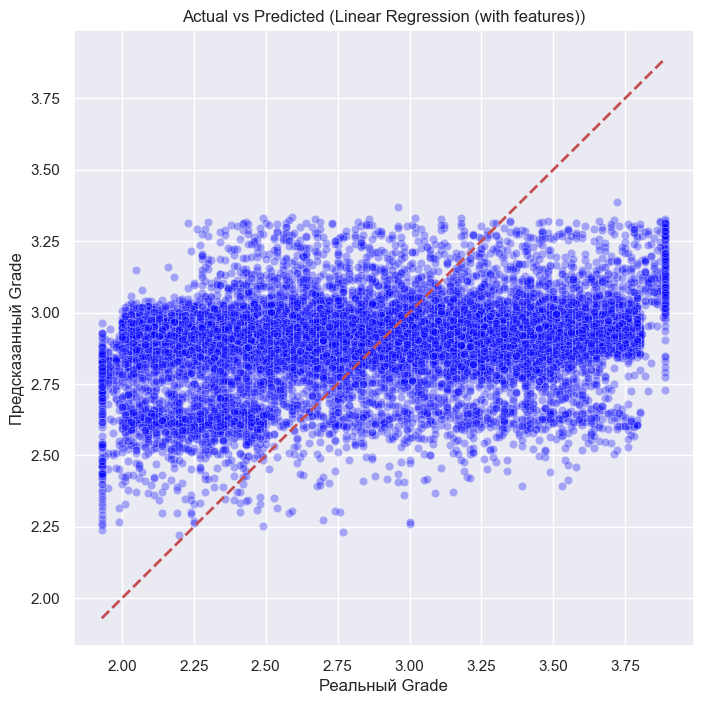

In [1445]:
def add_custom_features(x):
    x['sleep_deviation'] = (x['sleep_hours'] - 7).abs() # отклонение от нормы сна (7 – база)
    x['stress_sleep_impact'] = x['stress'] / (x['sleep_hours'] + 1) # индекс выгорания
    x['study_with_stress_ratio'] = x['study_hours'] * x['stress'] # учёба под давлением
    x['recovery_social_ratio'] = x['sleep_hours'] / (x['social_hours'] + 1) # отдых от social media
    x['recovery_study_ratio'] = x['sleep_hours'] / (x['study_hours'] + 1) # отдых от учёбы


x_feat_reg = df.drop(columns=['grade'])
y_feat_reg = df['grade']

add_custom_features(x_feat_reg)

feat_metrics = regression_metrics(x_feat_reg, y_feat_reg, "Linear Regression (with features)", prev_metrics=raw_metrics,
                                  use_poly=True)


## Классификация

In [1446]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, \
    roc_curve


def evaluate_classification(y_true, y_pred, y_proba, dataset_name, feature, weights, prev_metrics=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0

    current_metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC-ROC': auc_roc
    }

    descriptions = {
        'Accuracy': 'доля правильных ответов (общая точность)',
        'Precision': 'точность (способность отличать этот класс от других)',
        'Recall': 'полнота (способность находить все объекты этого класса)',
        'F1': 'гармоническое среднее между точностью и полнотой',
        'AUC-ROC': 'качество разделения классов моделью (чем выше, тем лучше)'
    }

    print(f"\n📊 Метрики классификации для {dataset_name}:")

    for key, val in current_metrics.items():
        diff_str = ""
        if prev_metrics and key in prev_metrics:
            diff = val - prev_metrics[key]
            color = "+" if diff > 0 else ""
            diff_str = f" ({color}{diff:.4f})"

        desc = descriptions.get(key, "")
        print(f"  {key:9}: {val:.4f}{diff_str}    – {desc}")

    importance = pd.DataFrame({'feature': feature, 'weight': weights.flatten()})
    importance = importance.sort_values(by='weight', ascending=False, key=lambda x: x.abs())

    print("\n=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===")
    print(importance.head(10))

    return current_metrics


def draw_classification_results(y_true, y_pred, y_proba, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f'Confusion Matrix: {name}')
    ax1.set_xlabel('Предсказание')
    ax1.set_ylabel('Реальность')

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_true, y_proba):.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve: {name}')
    ax2.legend(loc="lower right")

    plt.show()


def classification_task(x, y, name, use_poly=False, prev_metrics=None):
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )

    steps = []
    if use_poly:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
    steps.append(('scaler', StandardScaler()))

    # balanced сильнее штрафует за пропуск депрессии
    steps.append(('model', LogisticRegression(max_iter=1000, class_weight='balanced')))

    pipeline = Pipeline(steps)
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)
    y_proba = pipeline.predict_proba(x_test)[:, 1]

    if use_poly:
        feature_names = pipeline.named_steps['poly'].get_feature_names_out(x.columns)
    else:
        feature_names = x.columns

    weights = pipeline.named_steps['model'].coef_

    metrics = evaluate_classification(
        y_test, y_pred, y_proba, name,
        feature=feature_names,
        weights=weights,
        prev_metrics=prev_metrics
    )

    draw_classification_results(y_test, y_pred, y_proba, name)
    return metrics


📊 Метрики классификации для LogReg Base:
  Accuracy : 0.6224    – доля правильных ответов (общая точность)
  Precision: 0.1666    – точность (способность отличать этот класс от других)
  Recall   : 0.6877    – полнота (способность находить все объекты этого класса)
  F1       : 0.2682    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6868    – качество разделения классов моделью (чем выше, тем лучше)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
        feature    weight
4         grade -0.594841
3        stress  0.188812
1   sleep_hours -0.110350
0   study_hours  0.007511
2  social_hours  0.000798


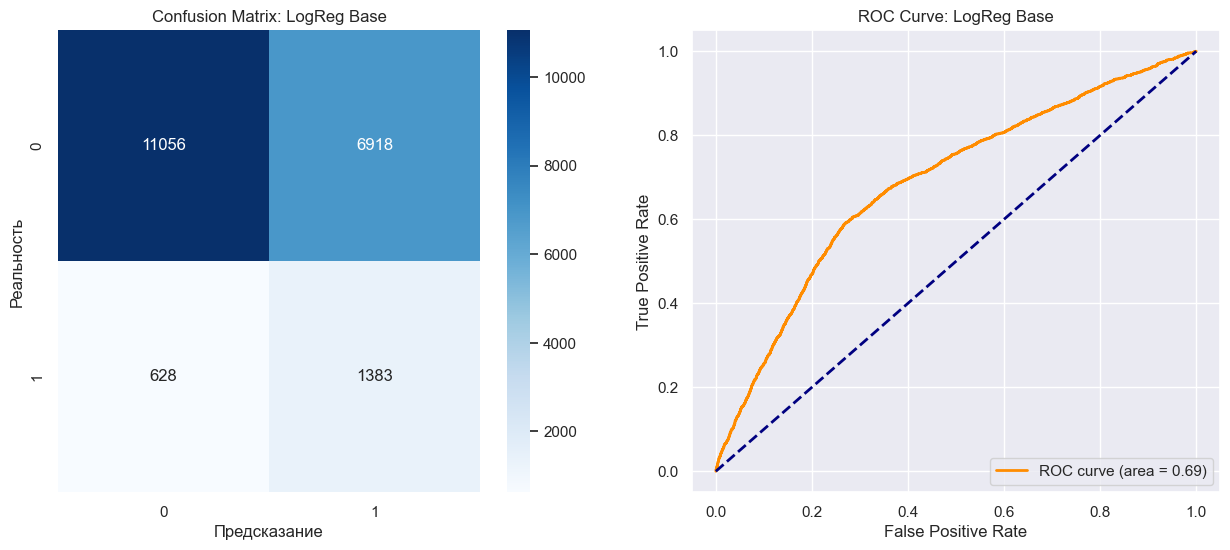


📊 Метрики классификации для LogReg Poly:
  Accuracy : 0.6326 (+0.0102)    – доля правильных ответов (общая точность)
  Precision: 0.1710 (+0.0044)    – точность (способность отличать этот класс от других)
  Recall   : 0.6892 (+0.0015)    – полнота (способность находить все объекты этого класса)
  F1       : 0.2740 (+0.0058)    – гармоническое среднее между точностью и полнотой
  AUC-ROC  : 0.6920 (+0.0052)    – качество разделения классов моделью (чем выше, тем лучше)

=== ВЛИЯНИЕ ПРИЗНАКОВ (TOP 10) ===
                   feature    weight
6      stress_sleep_impact  0.995691
4                    grade -0.599863
3                   stress -0.554132
1              sleep_hours  0.350461
5          sleep_deviation -0.079316
0              study_hours  0.041423
8    recovery_social_ratio -0.030713
7  study_with_stress_ratio -0.024301
2             social_hours -0.018893
9     recovery_study_ratio  0.017903


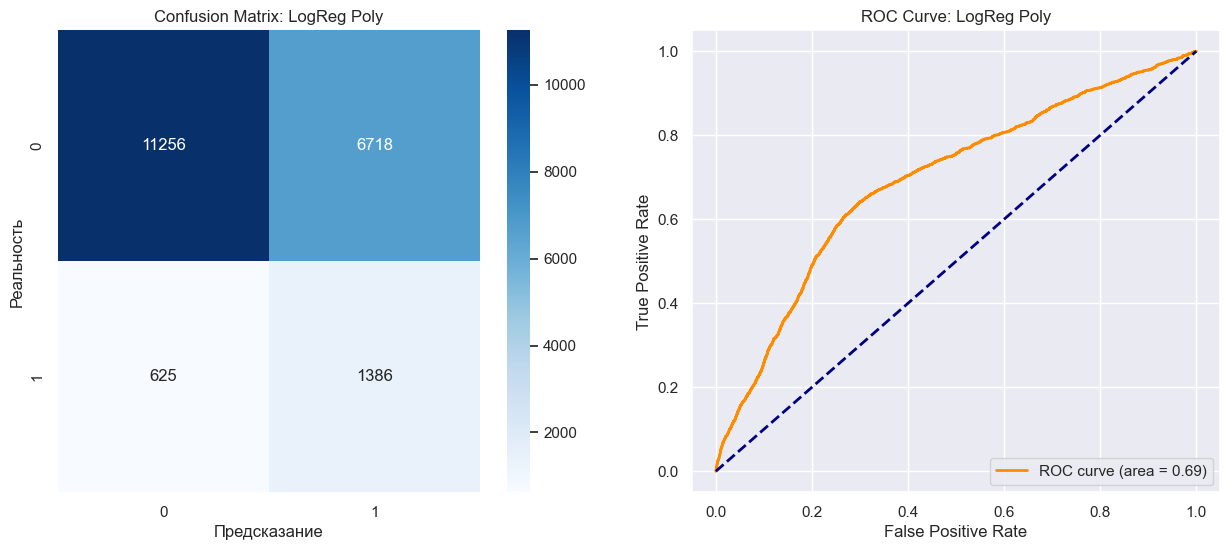

In [1447]:
x_class = df.drop(columns=['depression'])
y_class = df['depression']

base_class_metrics = classification_task(x_class, y_class, "LogReg Base", use_poly=False)


add_custom_features(x_class)
poly_class_metrics = classification_task(x_class, y_class, "LogReg Poly", use_poly=False,
                                         prev_metrics=base_class_metrics)
